# Down Hurts More \U00002696
### Falls stir up more volatility than rises. The reason everyone gives is wrong.

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

Fischer Black spotted it in 1976 and gave it a name that has outlived its explanation. The
"leverage effect" says a falling share price raises a company's debt-to-equity ratio, making
what is left riskier. Neat, intuitive, and testable — because some assets have no debt at all.

> \U0001F4D3 **This is the plain-language layer.** The EGARCH fit, the news-impact curve and the
> lead-lag test are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do falls raise volatility more than rises? | Yes, clearly, and it survives every control. |
| Is it because of debt? | Almost certainly not. |
| How do we know? | Gold has no debt and shows it too. |
| Does it matter? | Yes — it is why put options cost more than calls. |

## 1 · The effect

In [2]:
from downhurts import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
r = assets[data.EQUITY]
ss = st.sign_split(r, 21, 5)
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions")
print(f"volatility over the next 5 days after an up day:   {ss['vol_after_up']:.1%}")
print(f"volatility over the next 5 days after a down day:  {ss['vol_after_down']:.1%}")
print(f"ratio: {ss['ratio']:.3f}x")

as-of 2026-06-30 | SPY: 7,764 sessions
volatility over the next 5 days after an up day:   13.5%
volatility over the next 5 days after a down day:  15.9%
ratio: 1.180x


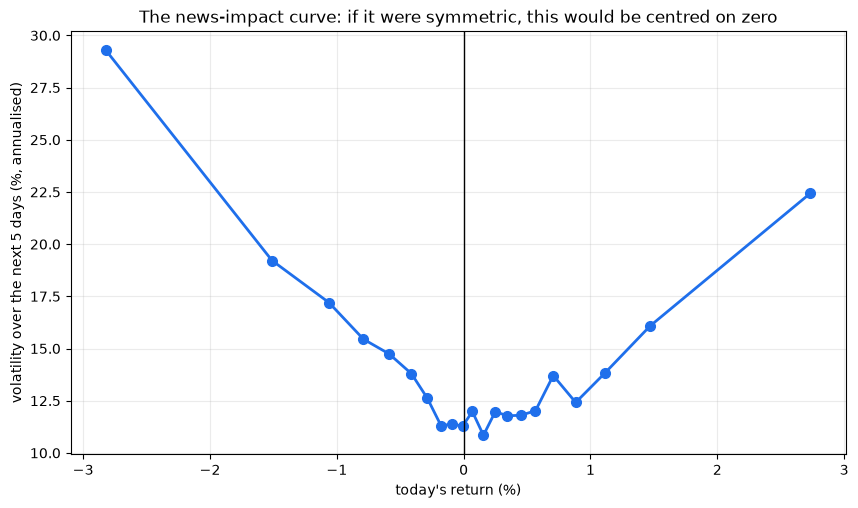

the curve bottoms out at a return of +0.28 standard deviations


In [3]:
nic = st.news_impact_curve(r, 5)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(nic["mean_return"] * 100, nic["mean_fwd_vol"] * 100, "o-", lw=2, ms=7,
        color="#1f6feb")
ax.axvline(0, color="k", lw=1)
cm = st.curve_minimum(nic)
ax.set_xlabel("today's return (%)")
ax.set_ylabel("volatility over the next 5 days (%, annualised)")
ax.set_title("The news-impact curve: if it were symmetric, this would be centred on zero")
plt.show()
print(f"the curve bottoms out at a return of {cm['vertex_z']:+.2f} standard deviations")

> \U0001F52C **For the quants.** The vertex is the summary statistic worth quoting. An up/down
> mean difference throws away the shape; the vertex uses the whole curve and is far less
> sensitive to where you put the dividing line.

## 2 · The obvious objection

Down days are *bigger* than up days — markets fall faster than they rise. And big moves are
followed by volatility whatever direction they went. So is this just a size effect wearing a
sign?

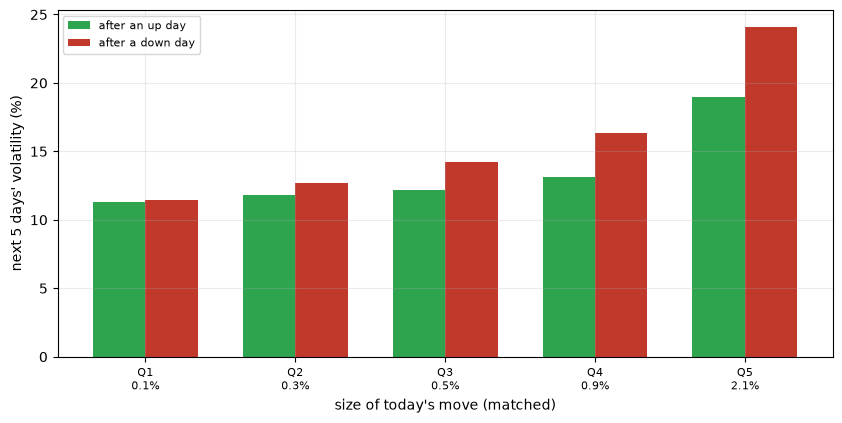

        mean_abs_move  vol_after_up  vol_after_down  ratio
bucket                                                    
Q1             0.0008        0.1132          0.1144 1.0110
Q2             0.0028        0.1185          0.1266 1.0688
Q3             0.0054        0.1221          0.1422 1.1641
Q4             0.0093        0.1315          0.1637 1.2445
Q5             0.0209        0.1900          0.2411 1.2687

average within-bucket ratio: 1.151x


In [4]:
mm = st.magnitude_matched_split(r, 5)
fig, ax = plt.subplots(figsize=(10, 4.5))
w = 0.35
xs = np.arange(len(mm))
ax.bar(xs - w / 2, mm["vol_after_up"] * 100, w, label="after an up day", color="#2ea44f")
ax.bar(xs + w / 2, mm["vol_after_down"] * 100, w, label="after a down day", color="#c0392b")
ax.set_xticks(xs)
ax.set_xticklabels([f"{b}\n{m:.1%}" for b, m in zip(mm.index, mm["mean_abs_move"])],
                   fontsize=8)
ax.set_xlabel("size of today's move (matched)")
ax.set_ylabel("next 5 days' volatility (%)"); ax.legend(fontsize=8)
plt.show()
print(mm[["mean_abs_move", "vol_after_up", "vol_after_down", "ratio"]].round(4).to_string())
print(f"\naverage within-bucket ratio: {mm['ratio'].mean():.3f}x")

Comparing like with like, the asymmetry is still there. It is smaller than the raw number, which
is exactly what you would expect if part of the raw number was a size effect.

## 3 · So is it leverage?

Black's story: the share price falls, the company's debt stays the same, so debt-to-equity
rises, so the remaining equity is riskier. That story has a clean, brutal test — find an asset
with no debt.

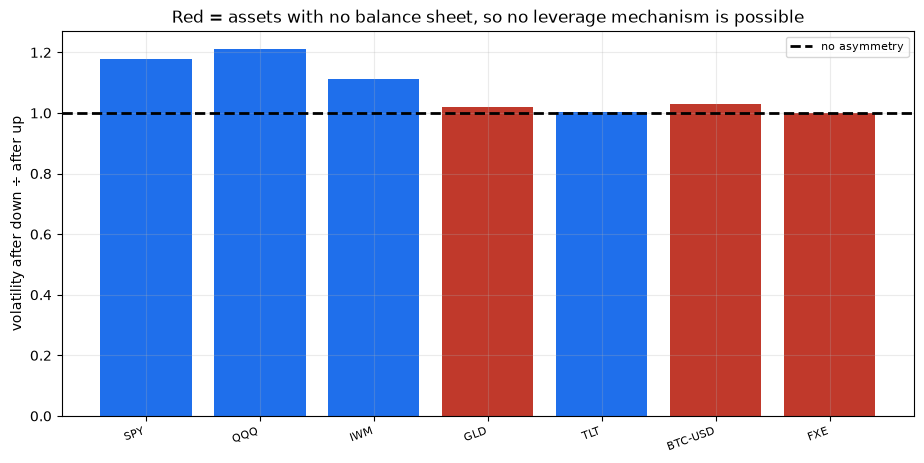

         ratio  corr_r_dvol  egarch_gamma
asset                                    
SPY     1.1797      -0.1165       -0.1098
QQQ     1.2103      -0.1014       -0.0819
IWM     1.1133      -0.1249       -0.0877
GLD     1.0185       0.0388        0.0509
TLT     1.0038      -0.0010       -0.0429
BTC-USD 1.0289      -0.0143       -0.0302
FXE     1.0008      -0.0234       -0.0046


In [5]:
p = st.panel(assets, 5, 21)
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#c0392b" if tk in (data.GOLD, data.CRYPTO, data.CURRENCY) else "#1f6feb"
          for tk in p.index]
ax.bar(range(len(p)), p["ratio"], color=colors)
ax.axhline(1.0, color="k", ls="--", lw=2, label="no asymmetry")
ax.set_xticks(range(len(p))); ax.set_xticklabels(p.index, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("volatility after down ÷ after up")
ax.legend(fontsize=8)
ax.set_title("Red = assets with no balance sheet, so no leverage mechanism is possible")
plt.show()
print(p[["ratio", "corr_r_dvol", "egarch_gamma"]].round(4).to_string())

Gold is a metal. It has no shareholders, no debt, no capital structure. Bitcoin is a number in a
ledger. Neither of them can possibly have a debt-to-equity ratio that rises when the price
falls — so if they show the effect, the mechanism is something else entirely.

The leading alternative is **volatility feedback**: when volatility rises, investors demand a
higher return to hold the asset, and the only way to offer a higher future return is a lower
price today. Same correlation, opposite direction of causality.

## 4 · Which way does the arrow point?

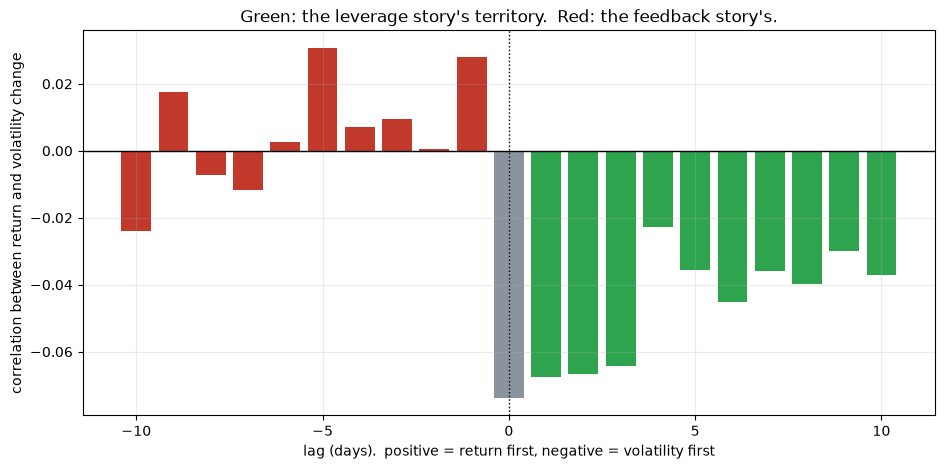

return leads volatility (leverage): -0.0513
volatility leads return (feedback): +0.0151
-> leans leverage


In [6]:
ll = st.lead_lag_asymmetry(r, 21)
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#2ea44f" if k > 0 else ("#c0392b" if k < 0 else "#8b949e") for k in ll.index]
ax.bar(ll.index, ll["correlation"], color=colors)
ax.axhline(0, color="k", lw=1); ax.axvline(0, color="k", lw=1, ls=":")
ax.set_xlabel("lag (days).  positive = return first, negative = volatility first")
ax.set_ylabel("correlation between return and volatility change")
ax.set_title("Green: the leverage story's territory.  Red: the feedback story's.")
plt.show()
w = st.which_story(ll)
print(f"return leads volatility (leverage): {w['leverage_side']:+.4f}")
print(f"volatility leads return (feedback): {w['feedback_side']:+.4f}")
print(f"-> leans {w['leans']}")

## 5 · Why you should care anyway

In [7]:
eg = st.egarch_asymmetry(r)
print(f"EGARCH gamma: {eg['gamma']:+.4f}")
print(f"a -1 sigma day raises volatility {eg['response_ratio']:.2f}x as much as a +1 sigma day")
print()
print("This is why a put costs more than an equally out-of-the-money call: the market")
print("knows that if the price gets there, volatility will be higher when it does.")

EGARCH gamma: -0.1098
a -1 sigma day raises volatility 1.25x as much as a +1 sigma day

This is why a put costs more than an equally out-of-the-money call: the market
knows that if the price gets there, volatility will be higher when it does.


## 6 · The verdict

**Signal: Confirmed.** For SPY over 7,764 sessions, volatility over the five days after a down day averaged **15.9%** against **13.5%** after an up day — a ratio of **1.18×**. That survives the obvious objection: matching on the *size* of the move (down days are bigger on average, and big moves are followed by volatility whatever their sign) leaves a ratio of **1.15×**. It survives honest inference too — block-bootstrapping the difference gives *t* = **+7.70** against the naive +9.37. And the parametric version agrees: EGARCH gamma = **-0.110**, implying a down shock raises volatility 1.25× as much as an equal up shock. The news-impact curve bottoms out at **z = +0.28**, shifted toward positive returns exactly as the leverage story predicts.

**Tradability: Partial.** Now the part the name gets wrong. If financial leverage were the mechanism, assets with **no balance sheet** could not show the effect. Gold's ratio is 1.02× and Bitcoin's is 1.03×, against equities' 1.18× — and the effect is materially weaker there, which is at least consistent with the leverage story. The lead-lag test points the same way: the correlation between returns and *subsequent* volatility changes averages -0.051, against +0.015 for volatility leading returns — leaning **leverage**. For a hedger the practical content is the ratio itself: a 1.18× asymmetric response is why put skew exists and why a delta-hedged short-vol book bleeds asymmetrically. The name is wrong; the effect is real and it is priced.

## 7 · Going further \U0001F6AA

- **Individual stocks sorted by leverage.** If the mechanism were debt, high-debt firms should
  show a much stronger effect than debt-free ones. Figlewski & Wang (2000) checked; they do not.
- **High-frequency data.** Bollerslev, Litvinova & Tauchen (2006) run the lead-lag test on
  five-minute returns, where realised volatility is far less noisy and the arrow is much easier
  to see.
- **The option surface.** The asymmetry measured here should equal the skew the market is
  charging. Comparing them is a genuine test of whether the effect is fully priced.